# Occultation fitting with `juliet`

In this notebook, we will show how we can fit occultations using `juliet`. The basic method to fit occultations with `juliet` is very simple: you simply need to provide proper priors required to fit occultation signals. The first required parameter is the occultation depth, and the corresponding prior to use in `juliet` is `fp_p1_instrument`. Note that `fp_p1_instrument` is a planetary _and_ instrumental prior, i.e., we specify name of the planet (`p1` in this case) and the instrument (`instrument` in this case) together with `fp`. This allow us to provide seperate parameters for occultation depths for different instruments. For more details, see `multiple_instruments.ipynb` notebook. If we don't specify instrument with `fp` prior, i.e., if we only provide `fp_p1`, `juliet` will assume the same occultation depths for _all_ instruments. In this notebook, we will only use one instrument, so we can use `fp_p1`. `multiple_instruments.ipynb` notebook demonstrates how we can specify `fp_p1` prior for multiple instruments.

The second parameter needed for occultation fitting is the occultation time. There are two methods to parametrize occultation time in `juliet`. First, we can simply provide a prior for occultation time and directly fit for occultation time. This can be done by providing prior on `t_secondary_p1` (as in secondary eclipse time). However, it is possible to self consistently calculate occultation time given the orbital parameters. `juliet` can do this by providing keyword arguments `light_travel_delay=True` and `stellar_radius=rst` in `juliet.fit`. `juliet` will then self-consistently calculate occultation time along with light travel time delay. We will demonstrate both methods below.

Let's first load the necessary modules first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gd
import seaborn as sns
import plotstyles
import juliet
import os

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


For the purpose of this analysis, we will use TESS observations of hot Jupiter WASP-18 b. We have already downloaded all data and put them in Data folder.

We will also need some planetary parameters for this analysis. So, let's load some planetary parameters. All parameters are taken from [Cortés-Zuleta et al. 2020](https://ui.adsabs.harvard.edu/abs/2020A%26A...636A..98C/abstract)

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Cortés-Zuleta et al. 2020)
per, per_err = 0.94145223, 0.00000024           # Orbital period in days
t0, t0_err = 2456740.80560, 0.00019             # Transit epoch in BJD
rprs, rprs_err = 0.1018, 0.0011                 # Planet-to-star radius ratio
b, b_err = 0.36, np.sqrt(0.11**2 + 0.18**2)     # Impact parameter
rho, rho_err = 0.795*1e3, np.sqrt(0.110**2+0.089**2) * 1e3  # Stellar density in kg/m3

## Method 1: providing prior on `t_secondary_p1`

In this case, we will directly fit for occultation time. This can be useful, for example, when there is only occultation signal in the data. As mentioned before, we will use TESS data of a hot Jupiter WASP-18 b. In particular, we will use Sector 96 observations, so, this will be about 30 days of continuous observation of WASP-18. As a result, it will contain both transit and occultations. However, since we wanted to demonstrate "occultation only" analysis, we have masked transits from this dataset.

Let's load and plot the dataset.

(0.0, 24.205993593204767)

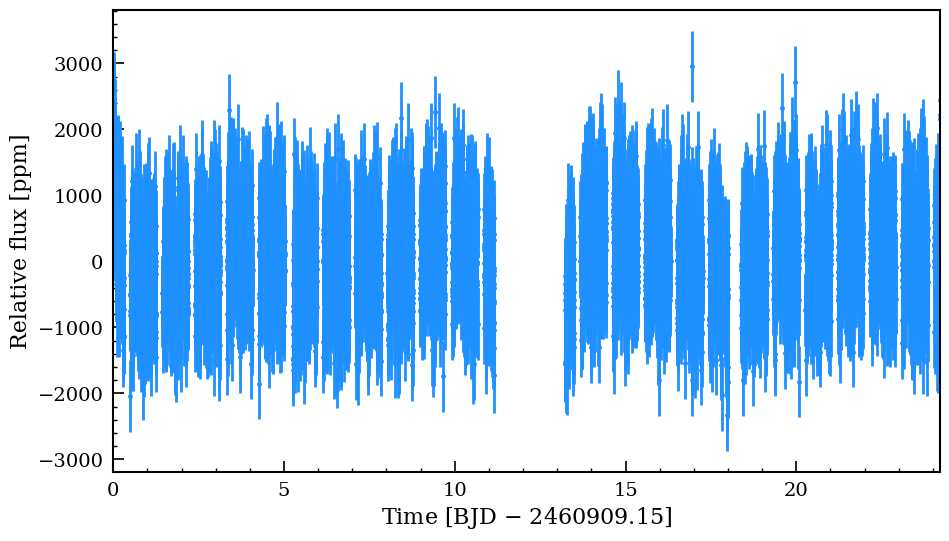

In [3]:
tim96, fl96, fle96 = np.loadtxt(os.getcwd() + '/Data/WASP-18_only_eclipse_TESS96.dat',\
                                usecols=(0,1,2), unpack=True)

# Ploting the data
fig, axs = plt.subplots()
axs.errorbar(tim96-tim96[0], (fl96-1)*1e6, yerr=fle96*1e6, fmt='.', color='dodgerblue')
axs.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim96[0]))
axs.set_ylabel('Relative flux [ppm]')
axs.set_xlim(0., np.max(tim96-tim96[0]))

There are several things to notice in the dataset. There is only occultation in the data (I mean, of course, we cannot see it, but there is, believe me) and there is no transit. So, we can _only_ fit for occultation and we don't have to worry about transits. We can do this by _not_ providing priros for limb darkening coefficients. Another things is that there is long-term, quadratic like, and probably short-term, trend in the dataset. This is most likely instrumental noise. We will simply use Gaussian processes to fit for this correlated noise.

As you probably know by now, in `juliet`, we provide appropriate priors to select model to fit the dataset. As mentioned before, if we provide priors on `fp_p1` and `t_secondary_p1`, `juliet` will know that we want to fit for occultation. Since we don't want to fit transits, we will not provide priors on the limb-darkening coefficients. And since there is no transit in the dataset, it would be hard to fit for other planetary and orbital parameters, so we will fix all of them to their literature values. For Gaussian process, we will use a Simple Harmonic Oscillator (SHO) kernel.

So, let's load the data and generate priros:

In [4]:
# Instrument name
instrument = 'TESS96'

# Creating data dictionaries the way juliet understands
tim_occ, fl_occ, fle_occ = {}, {}, {}
tim_occ[instrument], fl_occ[instrument], fle_occ[instrument] = tim96, fl96, fle96

### Predicting transit and occultation time for our observations
cycle = round((tim96[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters (no limb-darkening coefficients since we only model occultations)
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'fp_p1', 't_secondary_p1', 'ecc_p1', 'omega_p1', 'rho']
dist_P = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'normal', 'fixed', 'fixed', 'fixed']
hyper_P = [per, tc, rprs, b, [0., 1000.e-6], [tsec, tsec_err], 0., 90., rho]

## Instrumental priors
par_ins = ['mdilution_' + instrument, 'mflux_' + instrument, 'sigma_w_' + instrument]
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1.0, [0., 0.1], [0.1, 10000]]

## GP priors
par_gp = ['GP_S0_' + instrument, 'GP_omega0_' + instrument, 'GP_Q_' + instrument]
dist_gp = ['uniform', 'uniform', 'fixed']
hyper_gp = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_ins + par_gp
dist_tot = dist_P + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_ins + hyper_gp

# Generating priors in a way juliet understands
priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And, the actual `juliet` fitting:

In [5]:
# Output folder
pout = os.getcwd() + '/Analysis/Ecl_only'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim_occ, y_lc=fl_occ, yerr_lc=fle_occ,\
                   GP_regressors_lc=tim_occ, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8)

23144it [05:22, 71.67it/s, batch: 3 | bound: 38 | nc: 1 | ncall: 551048 | eff(%):  4.107 | loglstar: 75857.721 < 75866.583 < 75864.041 | logz: 75839.577 +/-  0.177 | stop:  0.823]       


Let's plot the model now. We will plot the full model and the detrended phase-folded model, so that we can see the fitted occultation. For this, we first need to create all models.

In [6]:
# --------------------------------------------
#    Some planetary models
# --------------------------------------------
## Mflux and sigma_w (white noise)
mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)

# --------------------------------------------
#    Extracting all models
# --------------------------------------------
# Creating all models
model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
## Saving all models
all_models = res.lc.model[instrument]

# --------------------------------------------
#    Full fitted models
# --------------------------------------------
# Full fitted model:
full_median_model = model[1]
## Sample random full model (to show uncertainties)
sample_models = model[0]
idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
random_models = sample_models[idx_nsamps, :]

# --------------------------------------------
#    Detrended data
# --------------------------------------------
## GP model
gp_median_model = all_models['GP']
## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
## See, juliet paper to find their meanings
F1 = np.nanmedian( 1 / ( 1 + mflx ) )
F2 = 0.

# Detrended data and errors
detrended_data = ( fl96 - gp_median_model ) / F1 
detrended_errors = np.sqrt( fle96**2 + sigw**2 )
# Orbital phases
phases = juliet.utils.get_phases(t=tim96, P=per, t0=tc, phmin=0.8)

# --------------------------------------------
#    Detrended models
# --------------------------------------------
# Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
post_samps_new = res.posteriors['posterior_samples'].copy()
for i in post_samps_new.keys():
    if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
        post_samps_new[i] = np.zeros(len(post_samps_new[i]))

planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                     return_components=True, return_samples=True, evaluate_transit=True)

# Sorting indices according to orbital phases
idx_phs = np.argsort(phases)

# Detrended median model
detrended_median_model = planet_only_models[1][idx_phs]
## Corresponding phases
phases_of_detrended_model = phases[idx_phs]
## Random models to show uncertainties
sample_pl_models = planet_only_models[0][:, idx_phs]
idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
random_pl_models = sample_pl_models[idx_nsamps_pl, :]

# --------------------------------------------
#    Binned data for visuals
# --------------------------------------------
# Residuals and binned data
resids = fl96 - full_median_model

# Binned data
bin_phs, bin_det, bin_deterr = juliet.utils.bin_data(x=phases[idx_phs], y=detrended_data[idx_phs], n_bin=150, yerr=detrended_errors[idx_phs])
_, bin_res, bin_reserr = juliet.utils.bin_data(x=phases[idx_phs], y=resids[idx_phs], n_bin=150, yerr=detrended_errors[idx_phs])

Now that we have all models and data, we can finally plot the models. As we mentioned before, we will plot full model and detrended phase folded models.

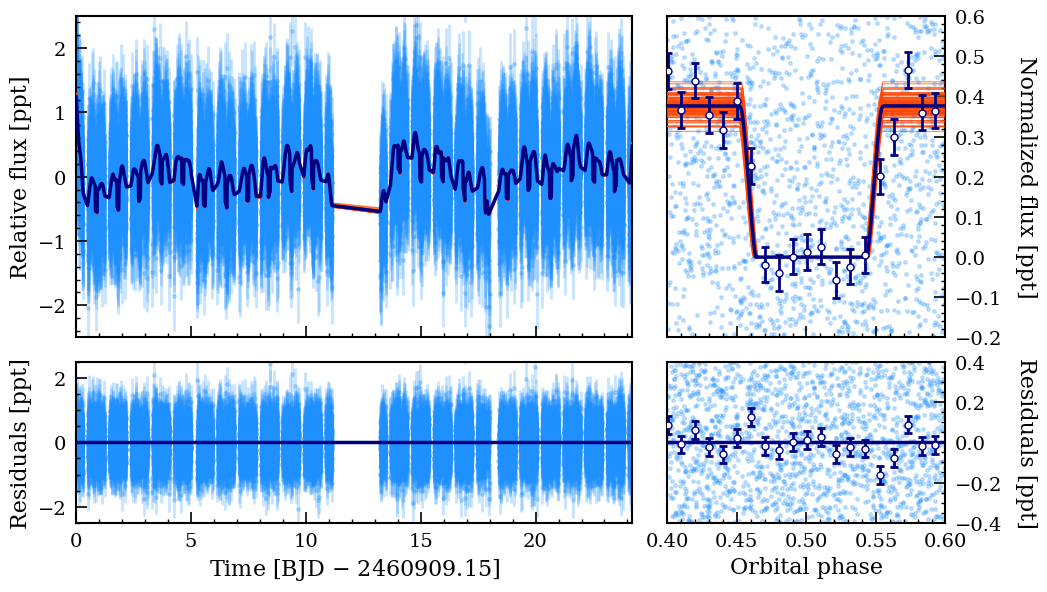

In [7]:
fig = plt.figure()
gs = gd.GridSpec(nrows=2, ncols=2, height_ratios=[2,1], width_ratios=[2,1])

axs1 = plt.subplot(gs[0,0])     # Top-left
axs2 = plt.subplot(gs[0,1])     # Top-right
axs3 = plt.subplot(gs[1,0])     # Bottom-left
axs4 = plt.subplot(gs[1,1])     # Bottom-right

## Top-left panel (full model)
axs1.errorbar(tim96 - tim96[0], (fl96 - 1.)*1e3, yerr=fle96*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
axs1.plot(tim96 - tim96[0], (full_median_model - 1.)*1e3, color='navy', lw=2.5, zorder=50)
for rand in range(100):
    axs1.plot(tim96 - tim96[0], (random_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)
axs1.set_xlim([0., np.max(tim96 - tim96[0])])
axs1.set_ylim([-2.5, 2.5])
axs1.set_ylabel('Relative flux [ppt]')
axs1.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom-left panel (residuals)
axs3.errorbar(tim96 - tim96[0], resids*1e3, yerr=fle96*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
axs3.axhline(0., color='navy', lw=2.5, zorder=50)
axs3.set_xlim([0., np.max(tim96 - tim96[0])])
axs3.set_ylim([-2.5, 2.5])
axs3.set_ylabel('Residuals [ppt]')
axs3.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim96[0]))

## Top-right panel (detrended model+data)
axs2.errorbar(phases_of_detrended_model, (detrended_data[idx_phs] - 1.)*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
axs2.plot(phases_of_detrended_model, (detrended_median_model - 1.)*1e3, color='navy', lw=2.5, zorder=50)
axs2.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
for rand in range(100):
    axs2.plot(phases_of_detrended_model, (random_pl_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)

axs2.set_ylabel('Normalized flux [ppt]', rotation=270, labelpad=25)
axs2.set_xlim([0.4, 0.6])
axs2.set_ylim([-0.2, 0.6])

axs2.yaxis.tick_right()
axs2.tick_params(labelright=True, labelfontfamily='serif')
axs2.yaxis.set_label_position('right')
axs2.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom-right panel (residuals)
axs4.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
axs4.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
axs4.axhline(0., color='navy', lw=2.5, zorder=50)
axs4.set_ylabel('Residuals [ppt]', rotation=270, labelpad=25)
axs4.set_xlabel('Orbital phase')
axs4.set_xlim([0.4, 0.6])
axs4.set_ylim([-0.4, 0.4])

axs4.yaxis.tick_right()
axs4.tick_params(labelright=True, labelfontfamily='serif')
axs4.yaxis.set_label_position('right')

plt.tight_layout()

So, it was an overall nice fitting. All systematic trends were removed by GP (left column). There is a nice occultation signal in the data (right column). Let's plot the posterior of the occultation depth and see how it looks.

In the right column of the figure, the light blue poits are the original unbinned data points, while the white points are the binned datapoints. The solid blue line shows the median fitted model, while the orange lines depict the rmodels calculated from the randomly selected posteriors. The latter is plotted to show the uncertainty in the model computation.

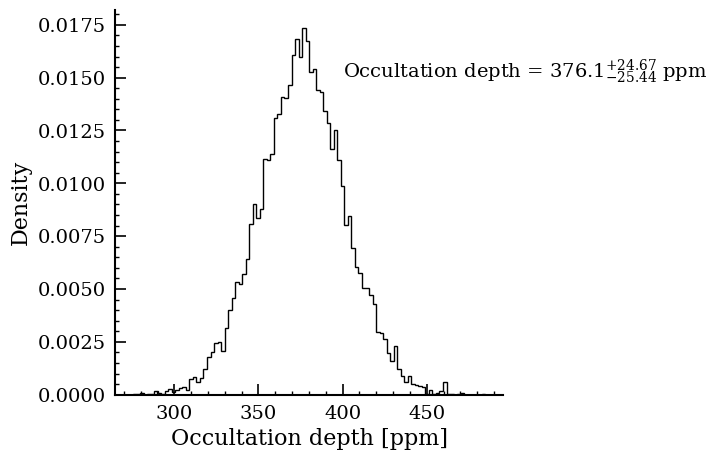

In [8]:
# Computing the confidence intervals for the occultation depth
qua = juliet.utils.get_quantiles(res.posteriors['posterior_samples']['fp_p1']*1e6)
fp_med, fp_up, fp_lo = qua[0], qua[1]-qua[0], qua[0]-qua[2]

fig, axs = plt.subplots(figsize=(5,5))
axs.hist(res.posteriors['posterior_samples']['fp_p1']*1e6, color='k', bins=100, histtype='step', density=True);
axs.text(400, 0.015, 'Occultation depth = ${' + str(np.around(fp_med,2)) + '}_{-' + str(np.around(fp_lo,2)) + '}^{+' + str(np.around(fp_up,2)) + '}$ ppm', fontsize=14)
axs.set_xlabel('Occultation depth [ppm]')
axs.set_ylabel('Density')

sns.despine()

Okay, it is nice posterior, with occultation depth of $376.49^{+25.49}_{-25.93}~\text{ppm}$. This value is slightly higher that the value reported by [Deline et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025A%26A...699A.150D/abstract) (they reported ~339 ppm). I think this is fine, since we only used one sector. Perhaps adding more data, and properly modelling the out-of-transit and out-of-occultation model can constrain the value properly.

Anyway, this was the one of the methods to fit the occultation model. There is another method which we will discuss now.

## Method 2: self-consistently calculating occultation time

Previously, we directly fitted for occultation time. However, as mentioned before, we can self-consistently calculate occultation time from the orbital paramters. Furthermore, light will take finite time to travel from the location of superior to inferior conjunctions. So, the light that we see in our observations are not emitted at the times we record it. We need to correct for this light travel time delay. In `juliet`, both of these things can be achieved by setting `light_travel_delay=True` keyword in `juliet.fit`. We also need to provide the stellar radius (in the units of Solar radius) to `juliet.fit` for this via `stellar_radius` keyword.

Setting `light_travel_delay=True` and providing `stellar_radius` to `juliet.fit` allows `juliet` to self-consistently calculate occultation time using orbital parameters. Therefore, we can use the occultation time to constrain orbital parameters, in particular, eccentricity of the orbit. For non-zero eccentricity, the occultation will be away from $t_0 \pm P/2$ (where, $t_0$ and $P$ are transit time and orbital period, respectively). So, if we can constrain occultation properly to measure the occultation time precisely, we can can use that information to calculate eccentricity. We will also demonstrate that in the example below.

We will again use TESS observations of WASP-18 system in this example. However, this time we will use data from Sector 69. Let's load and plot the dataset.

(0.0, 23.77811924321577)

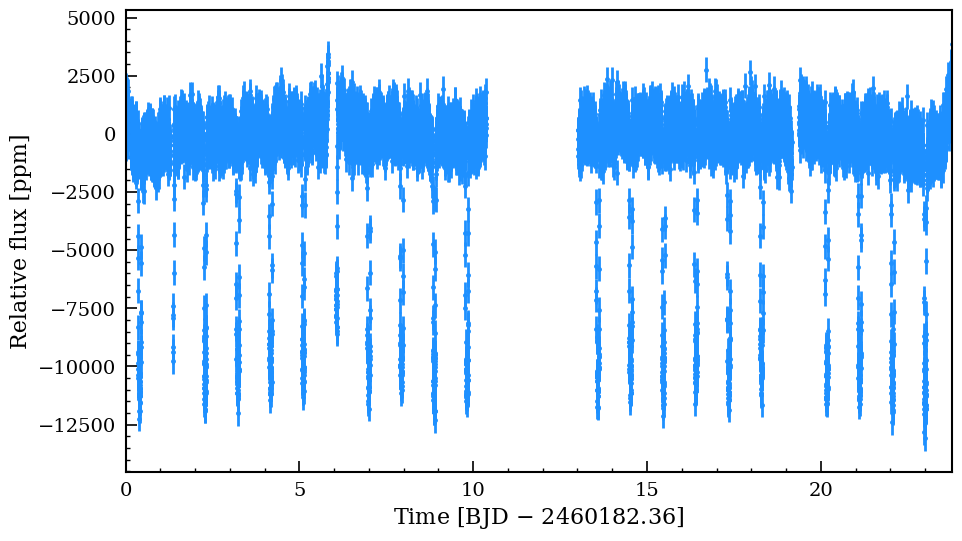

In [9]:
tim69, fl69, fle69 = np.loadtxt(os.getcwd() + '/Data/WASP-18_TESS69.dat',\
                              usecols=(0,1,2), unpack=True)

# Ploting the data
fig, axs = plt.subplots()
axs.errorbar(tim69-tim69[0], (fl69-1)*1e6, yerr=fle69*1e6, fmt='.', color='dodgerblue')
axs.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim69[0]))
axs.set_ylabel('Relative flux [ppm]')
axs.set_xlim(0., np.max(tim69-tim69[0]))

As can be see, now there are transits in the data as well, so we need to fit them, in addition to the occultation and systematic noise. Transit _and_ occultation fitting can be enabled by providing priors on limb darkening coefficients (`q1` and `q2`) _and_ occultation depth (`fp`). We also want to constrain eccentricity and argument of periastron from constraints on occultation time. So, we will not fix eccentricity and argument of periastron. We will use `sesinomega`-`secosomega` parametrization for fitting eccentricity and argument of periastron.

In [10]:
# Instrument name
instrument = 'TESS69'

# Creating data dictionaries the way juliet understands
tim, fl, fle = {}, {}, {}
tim[instrument], fl[instrument], fle[instrument] = tim69, fl69, fle69

### Predicting transit and occultation time for our observations
cycle = round((tim69[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_' + instrument, 'q2_' + instrument, 'rho']
dist_P = ['normal', 'normal', 'normal', 'normal', 'uniform', 'uniform', 'normal']
hyper_P = [[per, per_err], [tc, tc_err], [rprs, 3*rprs_err], [b, 3*b_err], [0., 1.], [0., 1.], [rho, rho_err]]
## Occultation depth
par_fp = ['fp_p1']
dist_fp = ['uniform']
hyper_fp = [[0., 1000.e-6]]
## Eccentricity and argument of periastron
par_ecc = ['sesinomega_p1', 'secosomega_p1']
dist_ecc = ['uniform', 'uniform']
hyper_ecc = [[-0.5, 0.5], [-0.5, 0.5]]

## Instrumental priors
par_ins = ['mdilution_' + instrument, 'mflux_' + instrument, 'sigma_w_' + instrument]
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1.0, [0., 0.1], [0.1, 10000]]

## GP priors
par_gp = ['GP_S0_' + instrument, 'GP_omega0_' + instrument, 'GP_Q_' + instrument]
dist_gp = ['uniform', 'uniform', 'fixed']
hyper_gp = [[np.exp(-30.), np.exp(-15.)], [2*np.pi/10, 2*np.pi/0.1], 1/np.sqrt(2)]

# Total priors
par_tot = par_P + par_fp + par_ecc + par_ins + par_gp
dist_tot = dist_P + dist_fp + dist_ecc + dist_ins + dist_gp
hyper_tot = hyper_P + hyper_fp + hyper_ecc + hyper_ins + hyper_gp

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

As mentioned before we want to self-consistently calculate occultation time from orbital parameters. We will do this by setting `light_travel_delay=True` and providing `stellar_radius` to `juliet.fit` as shown below.

In [11]:
# Output folder
pout = os.getcwd() + '/Analysis/TraEcl'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle,\
                   GP_regressors_lc=tim, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=8, light_travel_delay=True, stellar_radius=1.29)

34588it [32:58, 17.48it/s, batch: 3 | bound: 32 | nc: 1 | ncall: 1107032 | eff(%):  3.079 | loglstar: 88938.529 < 88947.400 < 88943.948 | logz: 88897.273 +/-  0.245 | stop:  0.856]      


Now, let's plot the fitted models. We will fit the full model and the detrended models. We first need to compute various models as previously.

In [12]:
# --------------------------------------------
#    Some planetary models
# --------------------------------------------
## Mflux and sigma_w (white noise)
mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)

# --------------------------------------------
#    Extracting all models
# --------------------------------------------
# Creating all models
model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
## Saving all models
all_models = res.lc.model[instrument]

# --------------------------------------------
#    Full fitted models
# --------------------------------------------
# Full fitted model:
full_median_model = model[1]
## Sample random full model (to show uncertainties)
sample_models = model[0]
idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
random_models = sample_models[idx_nsamps, :]

# --------------------------------------------
#    Detrended data
# --------------------------------------------
## GP model
gp_median_model = all_models['GP']
## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
## See, juliet paper to find their meanings
F1 = np.nanmedian( 1 / ( 1 + mflx ) )
F2 = 0.

# Detrended data and errors
detrended_data = ( fl69 - gp_median_model ) / F1 
detrended_errors = np.sqrt( fle69**2 + sigw**2 )
# Orbital phases (for phase curve)
phases = juliet.utils.get_phases(t=tim69, P=per, t0=tc, phmin=0.8)

# --------------------------------------------
#    Detrended models
# --------------------------------------------
# Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
post_samps_new = res.posteriors['posterior_samples'].copy()
for i in post_samps_new.keys():
    if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
        post_samps_new[i] = np.zeros(len(post_samps_new[i]))

planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                     return_components=True, return_samples=True, evaluate_transit=True)

# Sorting indices according to orbital phases
idx_phs = np.argsort(phases)

# Detrended median model
detrended_median_model = planet_only_models[1][idx_phs]
## Corresponding phases
phases_of_detrended_model = phases[idx_phs]
## Random models to show uncertainties
sample_pl_models = planet_only_models[0][:, idx_phs]
idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
random_pl_models = sample_pl_models[idx_nsamps_pl, :]

# --------------------------------------------
#    Binned data for visuals
# --------------------------------------------
# Residuals and binned data
resids = fl69 - full_median_model

# Binned data (for phase curves)
bin_phs, bin_det, bin_deterr = juliet.utils.bin_data(x=phases[idx_phs], y=detrended_data[idx_phs], n_bin=150, yerr=detrended_errors[idx_phs])
_, bin_res, bin_reserr = juliet.utils.bin_data(x=phases[idx_phs], y=resids[idx_phs], n_bin=150, yerr=detrended_errors[idx_phs])

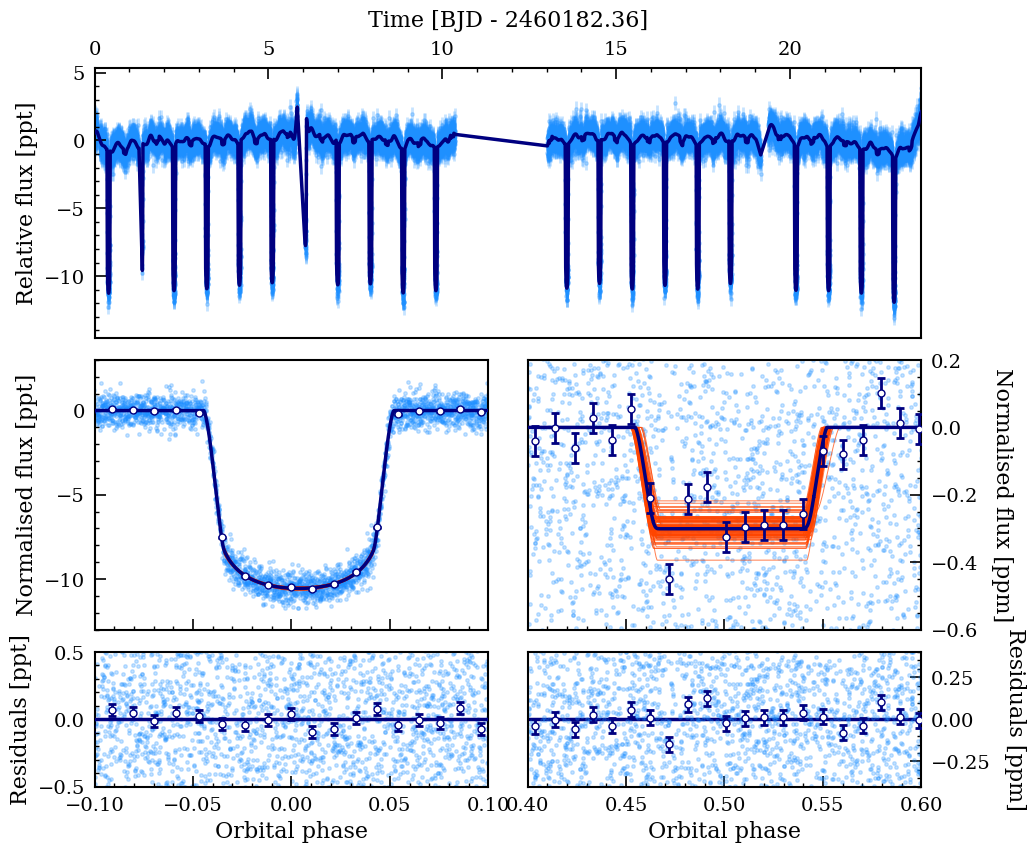

In [13]:
fig = plt.figure(figsize=(16/1.5, 14/1.5))
gs = gd.GridSpec(3, 2, height_ratios=[6,6,3], width_ratios=[2,2], hspace=0.1, wspace=0.1)

# Top panel (full model)
ax0 = plt.subplot(gs[0,:])
ax0.errorbar(tim69 - tim69[0], (fl69 - 1.)*1e3, yerr=fle69*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
ax0.plot(tim69 - tim69[0], (full_median_model - 1.)*1e3, c='navy', lw=2.5, zorder=50)
for rand in range(100):
    ax0.plot(tim69 - tim69[0], (random_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)

ax0.set_ylabel('Relative flux [ppt]', fontfamily='serif')
ax0.set_xlabel('Time [BJD - {:.2f}]'.format(tim69[0]), labelpad=10)
ax0.xaxis.tick_top()
ax0.xaxis.set_label_position('top')
ax0.set_xlim([0., np.max(tim69 - tim69[0])])

# Transit
xlim1, xlim2 = -0.1, 0.1
## -- Upper panel
ax1 = plt.subplot(gs[1,0])
ax1.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
ax1.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax1.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, color='navy', lw=2.5, zorder=50)
for i in range(100):
    ax1.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=10)

ax1.set_ylabel('Normalised flux [ppt]', fontfamily='serif')
ax1.set_xlim([xlim1, xlim2])
ax1.set_ylim([-13., 3.])
ax1.xaxis.set_major_formatter(plt.NullFormatter())

## -- Bottom panel
ax2 = plt.subplot(gs[2,0])
ax2.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', alpha=0.25, color='dodgerblue', zorder=1)
ax2.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=20)
ax2.axhline(0.0, lw=2.5, color='navy', zorder=10)

ax2.set_xlabel('Orbital phase', fontfamily='serif')
ax2.set_ylabel('Residuals [ppt]', fontfamily='serif')
ax2.set_xlim([xlim1, xlim2])
ax2.set_ylim([-0.5, 0.5])
ax2.tick_params(labelfontfamily='serif')


# Phase curve
xlim3, xlim4 = 0.4, 0.6

## Upper panel
ax3 = plt.subplot(gs[1,1])
ax3.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.25, c='dodgerblue', zorder=1)
ax3.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax3.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
for i in range(100):
    ax3.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, c='orangered', alpha=0.7, lw=0.7, zorder=10)


ax3.set_ylabel('Normalised flux [ppm]', rotation=270, labelpad=25, fontfamily='serif')
ax3.set_xlim([xlim3, xlim4])
ax3.set_ylim([-0.6, 0.2])
ax3.yaxis.tick_right()
ax3.tick_params(labelright=True, labelfontfamily='serif')
ax3.yaxis.set_label_position('right')
ax3.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom panel
ax4 = plt.subplot(gs[2,1])
ax4.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', color='dodgerblue', alpha=0.25)
ax4.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax4.axhline(0., lw=2.5, color='navy')

ax4.set_xlabel('Orbital phase', fontfamily='serif')
ax4.set_ylabel('Residuals [ppm]', rotation=270, labelpad=25, fontfamily='serif')
ax4.set_xlim([xlim3, xlim4])
ax4.set_ylim([-0.4, 0.4])
ax4.yaxis.tick_right()
ax4.tick_params(labelright=True, labelfontfamily='serif')
ax4.yaxis.set_label_position('right')

plt.tight_layout()

Beautiful! In this figure, the light blue poits are the original unbinned data points, while the white points are the binned datapoints. The solid blue line shows the median fitted model, while the orange lines depict the rmodels calculated from the randomly selected posteriors. The latter is plotted to show the uncertainty in the model computation.

A nice transit and occultation fitting. We successfully fitted transit and occultation. We mentioned before that we not only wanted to constrain occultation depth, but also eccentricity. So, let's look at the posteriors of occultation depth and eccentricity.

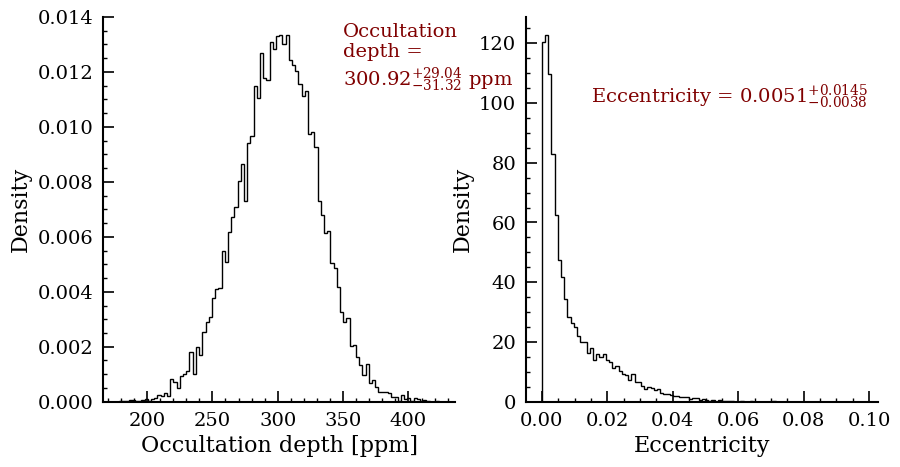

In [14]:
# Calculating eccentricity from sesinomega and secosomega
ecc = res.posteriors['posterior_samples']['sesinomega_p1']**2 +\
     res.posteriors['posterior_samples']['secosomega_p1']**2

# Computing the confidence intervals for the eccentricity and occultation depth
qua_fp = juliet.utils.get_quantiles(res.posteriors['posterior_samples']['fp_p1']*1e6)
fp_med, fp_up, fp_lo = qua_fp[0], qua_fp[1]-qua_fp[0], qua_fp[0]-qua_fp[2]

qua_ecc = juliet.utils.get_quantiles(ecc)
ecc_med, ecc_up, ecc_lo = qua_ecc[0], qua_ecc[1]-qua_ecc[0], qua_ecc[0]-qua_ecc[2]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axs[0].hist(res.posteriors['posterior_samples']['fp_p1']*1e6, color='k', bins=100, histtype='step', density=True);
axs[0].text(350, 0.0115, 'Occultation\ndepth = \n${' + str(np.around(fp_med,2)) + '}_{-' + str(np.around(fp_lo,2)) + '}^{+' + str(np.around(fp_up,2)) + '}$ ppm', color='maroon', fontsize=14)
axs[0].set_xlabel('Occultation depth [ppm]')
axs[0].set_ylabel('Density')

axs[1].hist(ecc, bins=100, color='k', histtype='step', density=True);
axs[1].text(0.015, 100, 'Eccentricity = ${' + str(np.around(ecc_med,4)) + '}_{-' + str(np.around(ecc_lo,4)) + '}^{+' + str(np.around(ecc_up,4)) + '}$', color='maroon', fontsize=14)
axs[1].set_xlabel('Eccentricity')
axs[1].set_ylabel('Density')

sns.despine()

Fantastic! Our value of occultation depth is within $1\sigma$ of the reported value in [Deline et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025A%26A...699A.150D/abstract) (~339 ppm). We also constrain consistent with zero eccentricity at $2\sigma$, which was also found by several authors in the literature (e.g., [Cortés-Zuleta et al. 2020](https://ui.adsabs.harvard.edu/abs/2020A%26A...636A..98C/abstract) found $e=0.00510^{+0.00700}_{-0.00370}$). Our results agrees very with their results.